# Projection of hidden states

**Цель: визуализировать "мысли" модели на промежуточных слоях путем раннего применения финального слоя-декодера (unembed) к остаточному потоку (residual stream).**

In [1]:
import os
import sys
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from grokking_carries.config import ModelConfig
from grokking_carries.model.transformer import GrokkingCarriesTransformer
from grokking_carries.data.tokenizer import MathTokenizer

model_cfg = ModelConfig()
tokenizer = MathTokenizer()
model = GrokkingCarriesTransformer(model_cfg)

save_dir = os.path.abspath(os.path.join(project_root, "src", "grokking_carries", "model"))
save_path = os.path.join(save_dir, "grokking_model_5_epochs.pth")

model.load_state_dict(torch.load(save_path, map_location=model_cfg.device, weights_only=True))
model.to(model_cfg.device)
model.eval()

print(f"Модель загружена на {model_cfg.device}. Слоев: {model_cfg.n_layers}. Готов к Logit Lens.")

Модель загружена на cpu. Слоев: 4. Готов к Logit Lens.


# Residual flow interceptor function


**прогоняет его через `LayerNorm` + `Unembed` и возвращает матрицу вероятностей правильных токенов.**

In [2]:
def run_logit_lens(model, tokenizer, cfg, prompt, target):
    full_text = f"{prompt} {target}"
    tokens = tokenizer.encode(full_text, from_split=True)
    tokens_tensor = torch.tensor([tokens], dtype=torch.long).to(cfg.device)
    str_tokens = [tokenizer.i2v[t] for t in tokens]
    
    # Установка прослушки
    cache = {}
    def save_resid_hook(tensor, hook_name):
        cache[hook_name] = tensor.detach()
        return tensor

    hooks = [(f"blocks.{layer}.hook_resid_post", save_resid_hook) for layer in range(cfg.n_layers)]
    
    # Прогон
    with torch.no_grad():
        with model.hooks(fwd_hooks=hooks):
            _ = model(tokens_tensor)
            
    # Применение линзы
    n_preds = len(tokens) - 1
    lens_matrix = torch.zeros(cfg.n_layers, n_preds)
    target_tokens = tokens_tensor[0, 1:] 
    
    for layer in range(cfg.n_layers):
        hidden_states = cache[f"blocks.{layer}.hook_resid_post"][0] 
        
        # Насильно проецируем промежуточный вектор в словарь
        normalized_states = model.ln_final(hidden_states[:-1, :]) 
        logits = model.unembed(normalized_states)                 
        probs = F.softmax(logits, dim=-1)                         
        
        # Собираем вероятности только для ground-truth токенов
        for pos in range(n_preds):
            lens_matrix[layer, pos] = probs[pos, target_tokens[pos]].item()
            
    return lens_matrix, str_tokens

# Analysis using the addition example

**Посмотрим, на каком слое сеть осознает, что $1999+2=2001$ и потребуется перенос в следующий разряд.**

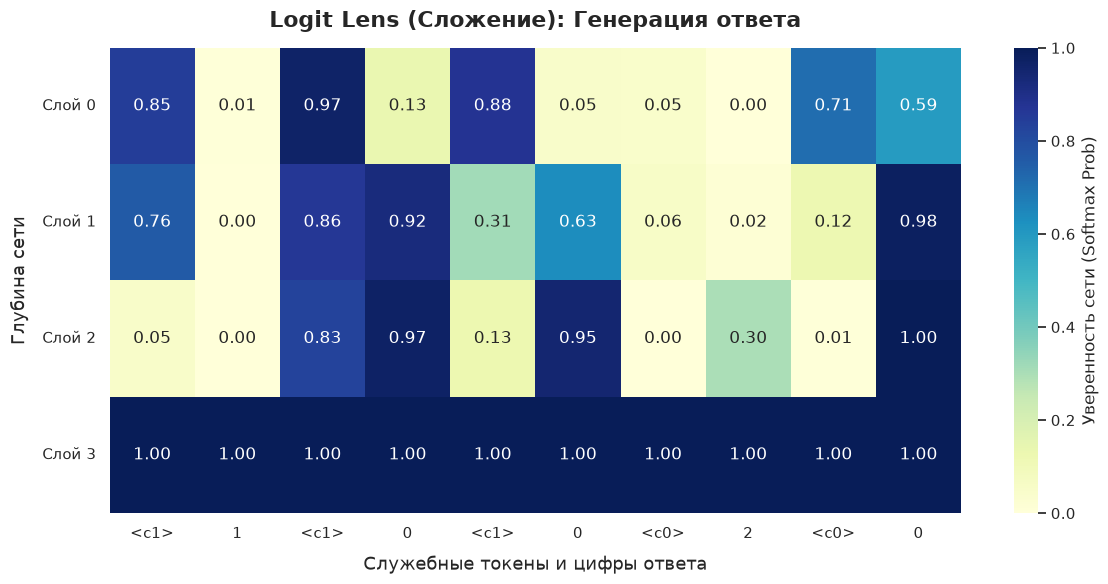

In [3]:
add_prompt = "0 1 9 9 9 + 0 0 0 0 2 ="
add_target = "<c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0"

lens_matrix_add, str_tokens_add = run_logit_lens(model, tokenizer, model_cfg, add_prompt, add_target)

eq_idx_add = str_tokens_add.index('=')
clean_lens_matrix_add = lens_matrix_add[:, eq_idx_add:]
clean_labels_add = str_tokens_add[eq_idx_add + 1:]

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.heatmap(
    clean_lens_matrix_add.cpu().numpy(),
    annot=True, fmt=".2f", cmap="YlGnBu",
    xticklabels=clean_labels_add, 
    yticklabels=[f"Слой {i}" for i in range(model_cfg.n_layers)],
    vmin=0, vmax=1,
    cbar_kws={'label': 'Уверенность сети (Softmax Prob)'}
)

plt.title("Logit Lens (Сложение): Генерация ответа", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Служебные токены и цифры ответа", fontsize=13, labelpad=10)
plt.ylabel("Глубина сети", fontsize=13, labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# Analysis using the example of subtraction

**Ранее мы выяснили, что L3H2 — переключатель вычитания.**
Проверим, отразится ли это на резком скачке вероятностей именно после 3-го слоя.

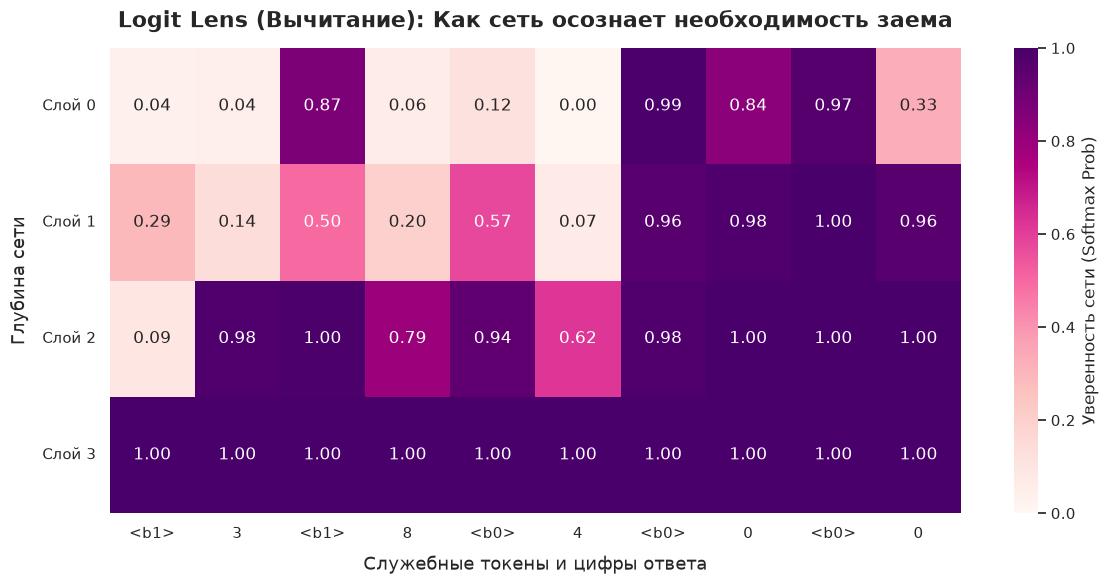

In [4]:
sub_prompt = "0 0 5 0 2 - 0 0 0 1 9 ="
sub_target = "<b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0"

lens_matrix_sub, str_tokens_sub = run_logit_lens(model, tokenizer, model_cfg, sub_prompt, sub_target)

eq_idx_sub = str_tokens_sub.index('=')
clean_lens_matrix_sub = lens_matrix_sub[:, eq_idx_sub:]
clean_labels_sub = str_tokens_sub[eq_idx_sub + 1:]

plt.figure(figsize=(12, 6))

sns.heatmap(
    clean_lens_matrix_sub.cpu().numpy(),
    annot=True, fmt=".2f", cmap="RdPu",
    xticklabels=clean_labels_sub, 
    yticklabels=[f"Слой {i}" for i in range(model_cfg.n_layers)],
    vmin=0, vmax=1,
    cbar_kws={'label': 'Уверенность сети (Softmax Prob)'}
)

plt.title("Logit Lens (Вычитание): Как сеть осознает необходимость заема", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Служебные токены и цифры ответа", fontsize=13, labelpad=10)
plt.ylabel("Глубина сети", fontsize=13, labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

**Модель откладывает разрешение логического конфликта на самый конец. И только на последнем слое окончательно вычисляется все необходимые вероятности и происходит резкий скачок до 100% уверенности по всей цепочке токенов. Без этого слоя корректное решение арифметической задачи невозможно.**

